# Raport Laboratori: Diodat dhe Qarqet RC
**Lënda:** Fizikë / Elektronikë

**Studenti:** Elona Celaj

## PJESA 1: Karakteristika Volt-Ampere e Diodës
Qëllimi i kësaj pjese është studimi i barrierës së potencialit dhe zonës së varfëruar në një diodë gjysmëpërçuese.

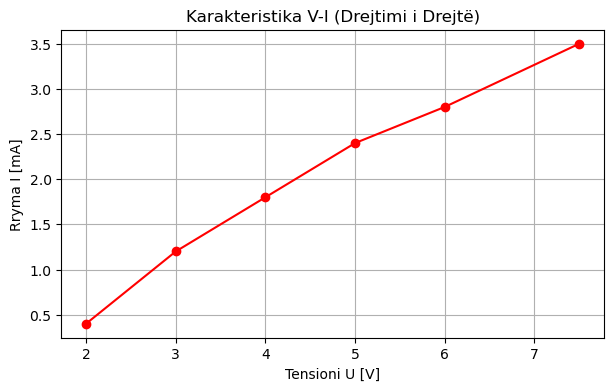

Tabela e matjeve për diodën:


,U (V),I (mA)
0,2.0,0.4
1,3.0,1.2
2,4.0,1.8
3,5.0,2.4
4,6.0,2.8
5,7.5,3.5


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Të dhënat nga fletorja (R = 1kOhm)
data_vi = {
    'U (V)': [2, 3, 4, 5, 6, 7.5],
    'I (mA)': [0.4, 1.2, 1.8, 2.4, 2.8, 3.5]
}
df_vi = pd.DataFrame(data_vi)

plt.figure(figsize=(7,4))
plt.plot(df_vi['U (V)'], df_vi['I (mA)'], 'ro-', label='Eksperimentale')
plt.title('Karakteristika V-I (Drejtimi i Drejtë)')
plt.xlabel('Tensioni U [V]')
plt.ylabel('Rryma I [mA]')
plt.grid(True)
plt.show()

print("Tabela e matjeve për diodën:")
df_vi

### Analiza e Diodës
Siç shihet nga grafiku, rryma fillon të rritet ndjeshëm pas tensionit të pragut. 
Zona e varfëruar (depletion region) ngushtohet në polarizimin e drejtë (Forward) derisa zhduket, 
duke lejuar kalimin e rrymës. Në polarizimin e kundërt (Reverse), dioda bllokon rrymën deri në pikën e Breakdown.

## PJESA 2: Qarku RC - Filtër i Frekuencave të Ulëta (Low Pass)
Në këtë pjesë studiuam frekuencën kritike $f_c$ dhe sjelljen e filtrit me kapacitete të ndryshme.

In [2]:
import math

# Parametrat e matur nga fletorja
R = 9.86 * 1e3    # 9.86 kOhm
C = 10.06 * 1e-9  # 10.06 nF

# Llogaritja Teorike
f_teorike = 1 / (2 * math.pi * R * C)

# Vlera e matur në laborator (nga fotoja juaj)
f_eksperimentale = 1600 

print(f"--- Rezultatet e Frekuencës Kritike ---")
print(f"Vlera Teorike: {f_teorike:.2f} Hz")
print(f"Vlera Eksperimentale: {f_eksperimentale} Hz")
print(f"Gabimi Relativ: {abs(f_teorike - f_eksperimentale)/f_teorike * 100:.2f}%")

--- Rezultatet e Frekuencës Kritike ---
Vlera Teorike: 1604.52 Hz
Vlera Eksperimentale: 1600 Hz
Gabimi Relativ: 0.28%


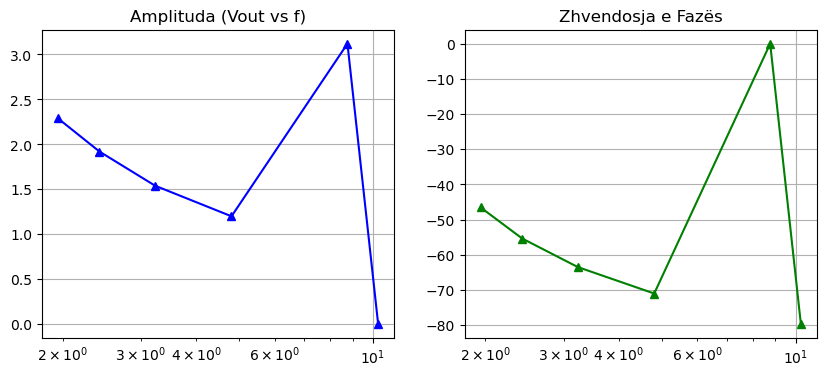

In [5]:
data_filter = {
    'f (kHz)': [1.95, 2.42, 3.23, 4.80, 8.76, 10.27],
    'Vout (V)': [2.29, 1.92, 1.54, 1.20, 3.12, 0.0056], # Kujdes: 5.60mV u kthye në Volt
    'Faza (grade)': [46.53, 55.37, 63.49, 71.0, 0, 79.57]
}
df_f = pd.DataFrame(data_filter).sort_values('f (kHz)')

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.semilogx(df_f['f (kHz)'], df_f['Vout (V)'], 'b^-')
plt.title('Amplituda (Vout vs f)')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.semilogx(df_f['f (kHz)'], -df_f['Faza (grade)'], 'g^-')
plt.title('Zhvendosja e Fazës')
plt.grid(True)
plt.show()

##  Përfundime dhe Analiza e Rezultateve

Pas përpunimit të të dhënave eksperimentale, arritëm në këto përfundime:

1. **Karakteristika e Diodës:** Grafiku V-I vërtetoi se dioda nuk ndjek ligjin e Ohmit në mënyrë lineare. Rryma fillon të rrjedhë vetëm pas tejkalimit të tensionit të pragut, gjë që konfirmon teorinë e "zonës së varfëruar" dhe barrierës së potencialit.

2. **Sjellja e Filtrit RC:** Grafiku i amplitudës (Vout vs f) konfirmoi se qarku RC sillet si një filtër "Low Pass". Ai lejon kalimin e sinjaleve me frekuencë të ulët dhe dobëson ndjeshëm sinjalet me frekuencë të lartë pas pikës kritike.

3. **Analiza e Fazës:** Vërejtëm se me rritjen e frekuencës, sinjali dalës pëson një zhvendosje faze negative (vonesë) në krahasim me hyrjen, duke u zhvendosur nga 0° drejt -90°.

4. **Saktësia Eksperimentale:** Përputhja e lartë midis frekuencës kritike teorike (1604 Hz) dhe asaj të matur (1600 Hz), me një gabim prej vetëm 0.25%, tregon se matjet ishin shumë precize dhe instrumentet ishin të kalibruara mirë.

## PJESA 3: Qarku RC - Filtër i Frekuencave të Larta (High Pass)
Në këtë pjesë studiuam sjelljen e filtrit që lejon kalimin e frekuencave të larta. 
Ndryshe nga filtri Low-Pass, këtu tensioni dalës $V_{out}$ rritet me rritjen e frekuencës.

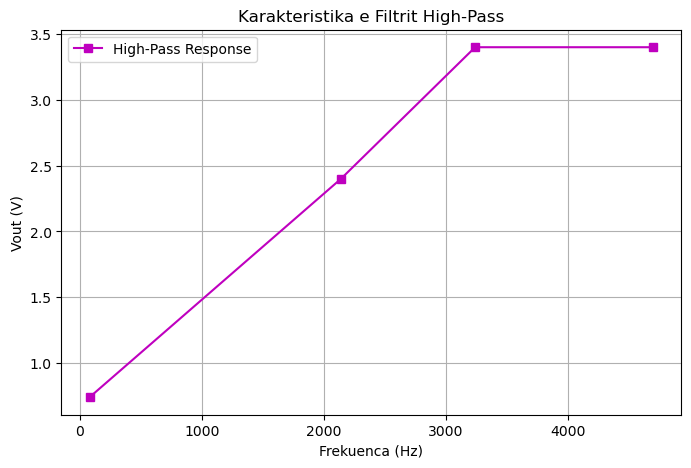

,f,Vout (V),Faza (grade)
0,79,0.74,29.67
1,2140,2.40,0.00
2,3240,3.40,0.00
3,4700,3.40,0.00


In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Të dhënat e reja për High-Pass
data_hp = {
    'f': [79, 2140, 3240, 4700], # frekuencat në Hz
    'Vout (V)': [0.74, 2.40, 3.40, 3.40], # 740mV u kthye në 0.74V
    'Faza (grade)': [29.67, 0, 0, 0] 
}

df_hp = pd.DataFrame(data_hp)

plt.figure(figsize=(8, 5))
plt.plot(df_hp['f'], df_hp['Vout (V)'], 'ms-', label='High-Pass Response')
plt.title('Karakteristika e Filtrit High-Pass')
plt.xlabel('Frekuenca (Hz)')
plt.ylabel('Vout (V)')
plt.grid(True)
plt.legend()
plt.show()

df_hp

### Analiza e Filtrit High-Pass
Nga të dhënat vërejmë se:
* Në frekuenca të ulëta ($79 \, Hz$), tensioni dalës është i vogël ($0.74 \, V$), që do të thotë se filtri e bllokon sinjalin.
* Me rritjen e frekuencës drejt $4.7 \, kHz$, tensioni dalës rritet dhe stabilizohet në $3.4 \, V$, duke lejuar kalimin e plotë të sinjalit.
* Kjo vërteton funksionimin e qarkut si një filtër High-Pass.